In [55]:
import numpy as np
from PIL import Image
import pickle
import matplotlib.pyplot as plt
from mnist import load_mnist

In [56]:
# 定义sigmoid函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))#这是公式定义的sigmoid函数
def softmax(a):
    # 处理二维情况（批量数据）
    if a.ndim == 2:
        c = np.max(a, axis=1, keepdims=True)#keepdims=True：保持维度
        # 防止溢出
        exp_a = np.exp(a - c)
        sum_exp = np.sum(exp_a, axis=1, keepdims=True)
        return exp_a / sum_exp
    # 处理一维情况
    else:
        c = np.max(a)
        exp_a = np.exp(a - c)
        sum_exp = np.sum(exp_a)
        return exp_a / sum_exp

In [57]:
# 读入数据
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(f"训练图像形状: {x_train.shape}")  # (60000, 784)
print(f"训练标签形状: {t_train.shape}")  # (60000,)
print(f"测试图像形状: {x_test.shape}")   # (10000, 784)
print(f"测试标签形状: {t_test.shape}")   # (10000,)

# 查看第一个训练样本
print(f"第一个样本的标签: {t_train[0]}")
print(f"第一个样本的像素范围: [{x_train[0].min()}, {x_train[0].max()}]")

# 使用不同参数加载
(x_train, t_train), (x_test, t_test) = load_mnist(
    normalize=True,     # 归一化
    flatten=False,      # 保持2D形状 (60000, 1, 28, 28)
    one_hot_label=True  # one-hot编码标签 (60000, 10)
)

训练图像形状: (60000, 784)
训练标签形状: (60000, 10)
测试图像形状: (10000, 784)
测试标签形状: (10000, 10)
第一个样本的标签: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
第一个样本的像素范围: [0.0, 1.0]


In [58]:
def cross_entropy_error(y, t):
    # 添加delta防止log(0)
    delta = 1e-7
    return -np.sum(t * np.log(y + delta)) / batch_size
def _numerical_gradient_no_batch(f, x):#处理单个样本
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 还原值
        
    return grad
def numerical_gradient(f, X):#（数值梯度）- 处理批量样本
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        
        return grad
def sigmoid_grad(x):
    """sigmoid函数的导数，x是sigmoid的输入"""
    s = sigmoid(x)
    return s * (1 - s)

In [59]:
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 初始化权重
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
    
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        return y
        
    # x:输入数据, t:监督数据
    def loss(self, x, t):
        y = self.predict(x)
        
        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
        
    # x:输入数据, t:监督数据
    def numerical_gradient(self, x, t):#（数值梯度）
        loss_W = lambda W: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
        
    def gradient(self, x, t):#（解析梯度/反向传播），更快
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward前向
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward反向
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

In [60]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True,one_hot_label=True)
# network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
network = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
# 超参数可以调
iters_num = 10000  # 适当设定循环的次数
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.05#学习率

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)#SGD底层
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 计算梯度
    grad = network.gradient(x_batch, t_batch)
    
    # 更新参数
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))


train acc, test acc | 0.09035, 0.0892
train acc, test acc | 0.5726833333333333, 0.5762
train acc, test acc | 0.8115, 0.8176
train acc, test acc | 0.8629666666666667, 0.8682
train acc, test acc | 0.8834666666666666, 0.8887
train acc, test acc | 0.8933, 0.8984
train acc, test acc | 0.89985, 0.904
train acc, test acc | 0.9040833333333333, 0.9084
train acc, test acc | 0.908, 0.9123
train acc, test acc | 0.9115333333333333, 0.916
train acc, test acc | 0.9143666666666667, 0.9185
train acc, test acc | 0.9167833333333333, 0.9197
train acc, test acc | 0.9181666666666667, 0.922
train acc, test acc | 0.9204166666666667, 0.9242
train acc, test acc | 0.9226833333333333, 0.9258
train acc, test acc | 0.9249833333333334, 0.9273
train acc, test acc | 0.9264166666666667, 0.9294


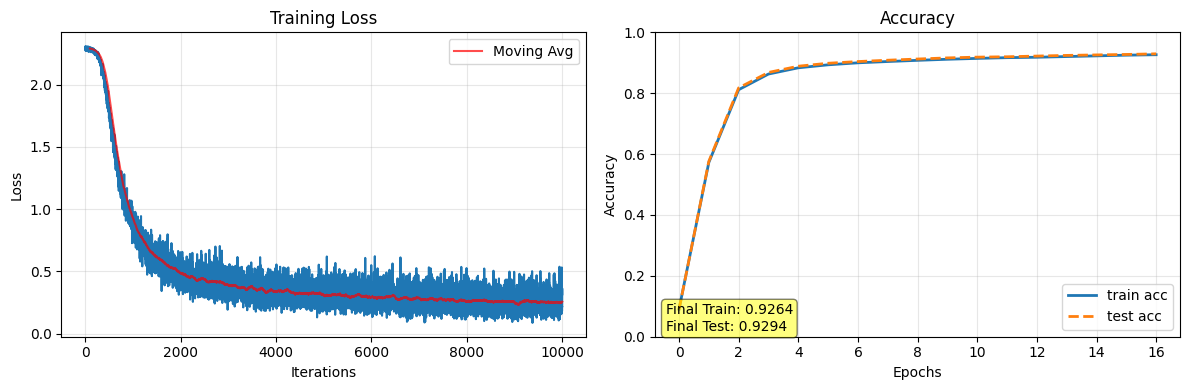


训练总结:
总迭代次数: 10000
批大小: 100
学习率: 0.05
最终训练损失: 0.315778
最终训练准确率: 0.9264
最终测试准确率: 0.9294


In [61]:
plt.figure(figsize=(12, 4))

# 子图1：损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_loss_list)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)

# 计算损失移动平均（更平滑）
if len(train_loss_list) > 100:
    window_size = 100
    moving_avg = np.convolve(train_loss_list, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(train_loss_list)), moving_avg, 'r-', alpha=0.7, label='Moving Avg')
    plt.legend()

# 子图2：准确率曲线
plt.subplot(1, 2, 2)
epochs = np.arange(len(train_acc_list))
plt.plot(epochs, train_acc_list, label='train acc', linewidth=2)
plt.plot(epochs, test_acc_list, label='test acc', linestyle='--', linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.title("Accuracy")
plt.grid(True, alpha=0.3)

# 添加准确率数值标注
if len(train_acc_list) > 0:
    final_train_acc = train_acc_list[-1]
    final_test_acc = test_acc_list[-1]
    plt.text(0.02, 0.02, f'Final Train: {final_train_acc:.4f}\nFinal Test: {final_test_acc:.4f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

plt.tight_layout()
plt.show()

# ================ 打印最终结果 ================
print("\n" + "="*50)
print("训练总结:")
print(f"总迭代次数: {iters_num}")
print(f"批大小: {batch_size}")
print(f"学习率: {learning_rate}")
print(f"最终训练损失: {train_loss_list[-1]:.6f}")
print(f"最终训练准确率: {train_acc_list[-1]:.4f}")
print(f"最终测试准确率: {test_acc_list[-1]:.4f}")
print("="*50)

## 阶段1：准备阶段
1问题定义与数据收集
2. 数据预处理（Data Preprocessing）
   - 加载数据
   - 数据清洗
   - 归一化/标准化
   - 划分数据集（训练集/验证集/测试集）
## 阶段2：模型构建阶段
   3. 搭建模型架构（Model Architecture）
       - 定义网络层
       - 确定激活函数
       - 设置初始化方法
    4. 选择损失函数（Loss Function）
    5. 选择优化器（Optimizer）
    6. 定义评估指标（Evaluation Metrics）
## 阶段3：训练阶段
   1.训练循环（Training Loop）
    for epoch in range(num_epochs):
        for batch in dataloader:
            a. 前向传播（Forward Pass）
            b. 计算损失（Compute Loss）
            c. 反向传播（Backward Pass）计算梯度
            d. 优化器更新参数（Optimizer Step）
            e. 梯度清零（Gradient Zero）
   2. 验证（Validation）
       - 在验证集上评估
       - 调整超参数（如需要）
       
   3. 保存模型检查点（可选）
 ## 阶段4：评估与部署阶段
   1最终评估（Final Evaluation）
   - 在测试集上评估
   - 分析模型性能
   2模型部署（Deployment）
